### 실습 1. 전처리 데이터 불러오기

 

해야 할 일

 

먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

 

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [2]:
import pandas as pd

# 1. CSV 파일 불러오기 (저장할 때 사용한 인코딩을 그대로 적어줍니다)
df_books = pd.read_csv('notebooks/book-text-ml/book_bestseller_clean.csv', encoding='utf-8-sig')

# 2. 전체 행과 컬럼 개수 확인
print("--- 데이터 크기 ---")
print(df_books.shape)

# 3. 컬럼 이름 확인
print("\n--- 컬럼 이름 목록 ---")
print(df_books.columns)

# 4. '상품명' 컬럼이 존재하는지 확인 (True/False로 알려줍니다)
print("\n--- '상품명' 컬럼 존재 여부 ---")
print('상품명' in df_books.columns)

# 5. 앞의 5행 확인
# 주피터 노트북에서 표를 깔끔하게 보기 위해 맨 마지막 줄에 작성합니다.
df_books.head()

--- 데이터 크기 ---
(199, 8)

--- 컬럼 이름 목록 ---
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')

--- '상품명' 컬럼 존재 여부 ---
True


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설


### 💾 정제된 데이터(CSV) 불러오기 결과 요약

* **불러오기 성공**: 방금 저장했던 `book_bestseller_clean.csv` 파일이 데이터 유실 없이 총 199행, 8열의 크기로 완벽하게 다시 불러와졌습니다.
* **한글 인코딩 확인**: 저장할 때 설정한 인코딩(`utf-8-sig`)이 잘 작동하여, '상품명'을 비롯한 모든 한글 컬럼명과 데이터가 깨짐 없이 정상적으로 표시됩니다.
* **전처리 상태 유지**: 상위 5행 데이터(`head()`)를 보면, 우리가 공들여 정리해 둔 **판매가(쉼표 없는 숫자)**와 **발행일(YYYY-MM-DD 모양)**이 그대로 예쁘게 잘 보존되어 있습니다.
* **의미**: 이제 데이터를 안전하게 파일로 보관하고 다시 꺼내 쓰는 사이클을 마스터하셨습니다! 앞으로는 복잡한 전처리 과정을 매번 반복할 필요 없이, 이 깨끗한 CSV 파일만 불러와서 바로 재미있는 데이터 분석을 시작하시면 됩니다. 🎉

### 실습 2. 분석할 도서 제목 확인하기



단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [3]:
print("=== 1. 상품명 원본 확인 (상위 20개) ===")
print(df_books["상품명"].head(20))

print("\n=== 2. 결측치(빈칸) 개수 확인 ===")
print("결측치 개수:", df_books["상품명"].isna().sum())

# === 3. 문자열 데이터 정제 (핵심) ===
# fillna(""): 만약 빈칸이 있다면 아무것도 없는 문자열("")로 채웁니다.
# astype(str): 모든 데이터를 확실하게 문자(글자)로 인식하게 만듭니다.
# str.strip(): 혹시 모를 글자 앞뒤의 쓸데없는 띄어쓰기를 지웁니다.
titles = df_books["상품명"].fillna("").astype(str).str.strip()

# === 4. 의미 없는 빈 문자열 제외 ===
# 데이터 중에 이름이 아예 없는("") 것들을 빼고 진짜 제목만 남깁니다.
titles = titles[titles != ""]

print("\n=== 5. 정제 완료 및 결과 확인 ===")
print("최종 사용할 제목 개수:", len(titles))
print("\n[정리된 데이터 앞의 5개]")
print(titles.head())

=== 1. 상품명 원본 확인 (상위 20개) ===
0                        소년이 온다
1                            모순
2                    결국 국민이 합니다
3                           혼모노
4                            급류
5                      초역 부처의 말
6                 청춘의 독서(특별증보판)
7                  어른의 행복은 조용하다
8                         채식주의자
9      단 한 번의 삶(강물에디션 활판인쇄 한정판)
10                     작별하지 않는다
11                          스토너
12           해커스 토익 기출 VOCA(보카)
13    다크 심리학(20만 부 한정판 스페셜 에디션)
14                 트렌드 코리아 2026
15                         위버멘쉬
16                          가공범
17                       듀얼 브레인
18         행동하지 않으면 인생은 바뀌지 않는다
19                  절창(화이트 에디션)
Name: 상품명, dtype: str

=== 2. 결측치(빈칸) 개수 확인 ===
결측치 개수: 0

=== 5. 정제 완료 및 결과 확인 ===
최종 사용할 제목 개수: 199

[정리된 데이터 앞의 5개]
0        소년이 온다
1            모순
2    결국 국민이 합니다
3           혼모노
4            급류
Name: 상품명, dtype: str


### 🏷️ 상품명(도서 제목) 정제 결과 요약

* **정제 완료**: 총 199개의 도서 제목 중 비어있는 데이터는 하나도 없었으며, 199개 모두 안전하게 정제되어 분석에 사용할 수 있게 되었습니다.
* **데이터 특징 발견 (중요)**: 
  * 상위 20개 제목을 눈으로 직접 확인해 보면 `(특별증보판)`, `(강물에디션 활판인쇄 한정판)`처럼 **괄호와 부제, 특수문자**가 포함된 경우가 아주 많습니다.
* **다음 분석을 위한 팁 (인사이트)**:
  * 제목을 단순히 띄어쓰기 기준으로만 쪼개게 되면 '독서(특별증보판)'처럼 괄호가 붙은 채로 단어가 분리되어 정확한 분석이 어려워집니다.
  * 워드클라우드나 단어 빈도 분석을 본격적으로 시작하기 전에, 이러한 특수기호들을 먼저 걸러내는 작업이 필요하다는 힌트를 얻을 수 있습니다!

### 실습 3. Dictionary로 단어 빈도 원리 이해하기

 

빈도 분석의 핵심은 매우 단순합니다.

 

같은 단어가 등장할 때마다 해당 단어의 숫자를 1씩 증가시키면 됩니다.

 

예를 들어 다음 단어가 있다고 가정합니다.

### 💡 단어 빈도 분석의 핵심 원리 (Dictionary 활용)

코드를 작성하기 전에, 컴퓨터가 단어의 개수를 세는 기본 원리를 먼저 이해해 봅니다. 
반장 선거에서 칠판에 이름 옆에 **바를 정(正)** 자를 그려가며 표를 세는 것과 완벽하게 똑같은 방식입니다!

* **1단계**: 기록할 빈 수첩(Dictionary)을 하나 준비합니다.
* **2단계**: 단어를 하나씩 읽으면서 수첩에 확인합니다.
  * 🆕 **처음 보는 단어라면?** ➡️ 수첩에 새로 적고 **1**이라고 기록합니다.
  * 🔄 **이미 수첩에 있는 단어라면?** ➡️ 기존 숫자에 **+1**을 해줍니다.
* **3단계**: 모든 단어를 다 읽을 때까지 이 과정을 반복합니다.

> **핵심 목표**: 복잡한 파이썬 문법을 달달 외우는 것이 아니라, **"처음이면 1, 있던 거면 +1"**이라는 아주 단순하고 직관적인 집계 원리를 이해하는 것입니다!

In [4]:
# 1. 예시 단어들이 들어있는 리스트(주머니) 준비
sample_words = [
    "데이터", "분석", "파이썬", "데이터", "AI", "분석", "데이터"
]

print("=== 방법 1: 직관적인 if ~ else 방식 ===")
word_counts_1 = {}  # 빈 수첩 준비

for word in sample_words:
    if word in word_counts_1:       # 이미 수첩에 적혀있는 단어라면?
        word_counts_1[word] += 1    # 기존 숫자에 1을 더한다 (+1)
    else:                           # 처음 보는 새로운 단어라면?
        word_counts_1[word] = 1     # 1부터 시작한다

print(word_counts_1)


print("\n=== 방법 2: 짧고 세련된 get() 방식 (결과는 똑같습니다!) ===")
word_counts_2 = {}  # 새로운 빈 수첩 준비

for word in sample_words:
    # get(word, 0): 수첩에 단어가 있으면 그 숫자를, 없으면 0을 가져온 뒤 1을 더합니다.
    word_counts_2[word] = word_counts_2.get(word, 0) + 1

print(word_counts_2)

=== 방법 1: 직관적인 if ~ else 방식 ===
{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}

=== 방법 2: 짧고 세련된 get() 방식 (결과는 똑같습니다!) ===
{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


### 📊 단어 빈도 집계(Dictionary) 실습 결과 요약

* **실행 결과 확인**: `if ~ else`를 사용한 기본 방식과 `get()`을 사용한 짧은 방식 모두 **{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}** 이라는 동일하고 정확한 결과를 출력했습니다.
* **알게 된 점**: 
  * 파이썬의 딕셔너리(`{}`)를 빈 수첩처럼 활용하면, 단어의 등장 횟수를 세는 '개표 작업'을 아주 쉽게 할 수 있습니다.
  * 코드가 어떻게 생겼든 **"처음 보는 단어면 1, 이미 있던 단어면 기존 숫자에 +1을 한다"**는 핵심 원리는 똑같이 작동한다는 것을 눈으로 확인했습니다.
* **다음 단계를 위한 의미**: 방금 연습한 이 7개 단어를 세는 단순한 원리가, 앞으로 진행할 '199권의 실제 베스트셀러 제목'에서 어떤 단어가 가장 많이 쓰였는지 분석하는 데 똑같이 그대로 사용됩니다!

### 실습 4. Counter로 같은 작업 간단하게 처리하기


Python에는 빈도 계산을 도와주는 Counter가 있습니다.

### 🚀 파이썬의 자동 계산기 `Counter` 활용하기

앞서 딕셔너리(`{}`)로 바를 정(正) 자를 직접 그려가며 계산 원리를 배웠다면, 이제는 파이썬이 미리 만들어둔 편리한 도구를 사용할 차례입니다.

* **`Counter`란?**: 우리가 방금 여러 줄로 길게 작성했던 '단어 개수 세기' 코드를 단 **한 줄**로 끝내주는 아주 편리한 자동 계산기입니다.
* **강력한 랭킹 기능 (`most_common`)**: 
  * 단어 개수를 세는 것을 넘어, 알아서 **가장 많이 나온 순서대로 순위(랭킹)**를 매겨줍니다.
  * 괄호 안에 숫자를 넣으면 (예: `most_common(3)`), 1등부터 3등까지만 쏙 뽑아서 보여줍니다.
* **왜 두 가지를 다 배우나요?**: 
  * 딕셔너리로 **"작동 원리(수작업)"**를 먼저 확실히 이해했기 때문에, 이제 `Counter`라는 **"편리한 도구(자동화)"**를 안심하고 마음껏 사용할 수 있습니다!

In [5]:
from collections import Counter

# 1. 앞에서 사용했던 예시 단어들
sample_words = [
    "데이터", "분석", "파이썬", "데이터", "AI", "분석", "데이터"
]

# 2. Counter를 이용해 단 '한 줄'로 단어 개수 세기
sample_counter = Counter(sample_words)
print("=== 1. Counter 기본 결과 ===")
print(sample_counter)

# 3. 가장 많이 등장한 순서대로(1등부터 꼴등까지) 정렬해서 보기
print("\n=== 2. 많이 나온 순서대로 보기 (most_common) ===")
print(sample_counter.most_common())

# 4. 상위 3등까지만 쏙 뽑아서 보기
print("\n=== 3. 상위 3개만 보기 ===")
print(sample_counter.most_common(3))

=== 1. Counter 기본 결과 ===
Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})

=== 2. 많이 나온 순서대로 보기 (most_common) ===
[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

=== 3. 상위 3개만 보기 ===
[('데이터', 3), ('분석', 2), ('파이썬', 1)]


### ⏱️ Counter 자동 집계 실습 결과 요약

* **단 한 줄의 마법**: 복잡한 조건문(`if~else`) 없이 `Counter()` 단 한 줄만으로 단어 개수를 완벽하게 세었습니다.
* **자동 랭킹 확인**: `most_common()` 함수를 사용하니, 가장 많이 등장한 '데이터(3번)'가 1등, '분석(2번)'이 2등으로 알아서 줄을 서는 것을 눈으로 확인했습니다.
* **원하는 순위만 자르기**: `most_common(3)`을 통해 전체 결과가 아닌 우리가 딱 보고 싶은 '상위 3개' 데이터만 깔끔하게 뽑아내는 것도 성공했습니다.
* **의미**: 딕셔너리로 빈도 분석의 '원리'를 깨우쳤고, 이제 `Counter`라는 '강력한 무기'까지 얻었습니다! 이제 실제 베스트셀러 도서 제목들에서 어떤 키워드가 가장 많이 쓰였는지 순위를 매겨볼 준비가 완벽하게 끝났습니다. 🚀

### 실습 5. pandas value_counts()로 빈도 확인하기

 

pandas에서도 같은 값이 몇 번 등장했는지 쉽게 확인할 수 있습니다.

### 🐼 pandas 전용 계산기 `value_counts()`와 3총사 비교

파이썬의 `Counter`처럼, 우리가 메인으로 사용하고 있는 **pandas** 안에도 단어 개수를 세어주는 아주 편리한 전용 기능이 있습니다. 바로 `value_counts()` 입니다!

**🏆 단어 빈도를 세는 3가지 방법 총정리**

어떤 값이 몇 번 나왔는지 세는 데는 여러 가지 방법이 있으며, 상황에 맞게 골라 쓰면 됩니다.

1. **Dictionary (`{}`)**
   * **특징**: 코드를 직접 짜서 하나씩 셉니다.
   * **의미**: 빈도 분석의 **기본 원리(수작업)**를 완벽하게 이해하기 위해 꼭 필요합니다.
2. **Counter (`collections`)**
   * **특징**: 파이썬이 기본으로 제공하는 자동 계산기입니다.
   * **의미**: 파이썬 리스트(`[]`) 데이터를 다룰 때, 가장 쉽고 빠르게 순위(`most_common`)를 뽑아볼 수 있습니다.
3. **value_counts() (`pandas`)**
   * **특징**: pandas 전용 도구입니다. 
   * **의미**: 데이터가 엑셀의 한 줄(Series) 형태로 되어 있을 때, 가장 직관적이고 자연스럽게 사용할 수 있습니다.

> **💡 핵심 인사이트**: "이것만 정답이다!" 하는 것은 없습니다. 원리를 이해했다면, 앞으로는 내가 분석하고 있는 데이터의 형태(리스트인지, pandas 표인지)에 따라 **가장 편한 도구를 자유롭게 골라서 사용**하시면 됩니다!

In [6]:
import pandas as pd

# 1. 앞에서 계속 사용 중인 예시 단어들
sample_words = [
    "데이터", "분석", "파이썬", "데이터", "AI", "분석", "데이터"
]

# 2. 파이썬 리스트(주머니)를 pandas의 Series(엑셀의 한 열) 형태로 변환하기
sample_series = pd.Series(sample_words)

# 3. value_counts()로 빈도 계산하고 결과 출력하기
print("=== pandas value_counts() 결과 ===")
print(sample_series.value_counts())

=== pandas value_counts() 결과 ===
데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64


### 📊 pandas `value_counts()` 실습 결과 요약

* **결과 확인**: 앞서 연습했던 Dictionary, Counter 방식과 완벽하게 동일한 결과('데이터' 3번, '분석' 2번)를 얻었습니다.
* **pandas만의 편리한 특징**: 
  * 결과를 출력할 때 **알아서 가장 많이 나온 순서대로(내림차순) 정렬**해서 보여줍니다.
  * 엑셀의 표처럼 세로로 깔끔하게 정리되어 있어, 나중에 표본이 많아져도 한눈에 알아보기 쉽습니다.
* **기초 훈련 완료**: 이제 단어의 개수를 세는 3가지 강력한 무기(Dictionary, Counter, value_counts)를 모두 획득하셨습니다! 데이터의 형태에 따라 가장 편한 도구를 자유롭게 골라 쓰시면 됩니다.

### 🚀 실무 팁: 대량 데이터 분석 시 성능 비교 (Counter vs value_counts)

실무에서 수십, 수백만 건의 대량 데이터를 다룰 때는 **pandas의 `value_counts()`**가 압도적으로 빠르고 성능이 좋습니다. 

* **왜 더 빠를까요?**: pandas는 내부적으로 계산 속도가 엄청나게 빠른 **C언어** 엔진 기반으로 만들어져 최적화되어 있기 때문입니다. 순수 파이썬 기능인 `Counter`는 데이터가 커질수록 처리 속도가 눈에 띄게 느려집니다.

**💡 실무 활용 가이드 (어떤 것을 써야 할까?)**
* 📊 **데이터가 이미 엑셀 표(pandas Series) 형태라면?** ➡️ 고민 없이 **`value_counts()`** 사용!
* 📝 **데이터가 단순한 파이썬 리스트(`[ ]`) 형태라면?** ➡️ 굳이 Series로 변환하는 시간을 쓰지 말고 바로 **`Counter`** 사용!

> **결론**: 우리는 이미 표 형태의 데이터(CSV)를 다루고 있으므로, 앞으로는 자연스럽게 **`value_counts()`**를 메인 무기로 사용하시면 됩니다!

### ✂️ 실습 6. 실제 도서 제목을 간단하게 단어로 쪼개보기

복잡한 한국어 분석(형태소 분석)에 들어가기 전에, 특수기호를 지우고 띄어쓰기를 기준으로 단어를 가볍게 쪼개어(토큰화) 분석의 전체 흐름을 테스트해 봅니다.

* **사용할 도구 (정규표현식)**: 쉼표나 느낌표 같은 특수기호는 무시하고, **순수한 한글, 영문, 숫자**만 쏙쏙 뽑아내는 간단한 규칙을 사용합니다. 영문은 묶어서 분석하기 쉽도록 모두 소문자로 통일합니다.
* **단순 쪼개기의 한계점 발견**:
  * `"AI 시대의 데이터 분석, Python으로 시작하기!"`를 쪼개면 어떻게 될까요?
  * 쪼갠 결과 ➡️ `['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']`
* **💡 핵심 인사이트 (왜 형태소 분석이 필요할까?)**:
  * 결과를 보면 '시대**의**', 'python**으로**' 처럼 **조사**가 단어에 그대로 찰거머리처럼 붙어 있습니다. 사람이 생각하는 진짜 '핵심 단어' 단위로 예쁘게 분리되지 않은 것이죠.
  * 이렇게 단순한 쪼개기의 명확한 한계를 눈으로 직접 확인했으니, 이제 **진짜 명사만 똑똑하게 뽑아내 주는 '형태소 분석'**을 배워야 할 완벽한 명분이 생겼습니다!

In [7]:
import re  # 텍스트에서 원하는 글자만 쏙쏙 뽑아내는 '정규표현식' 도구를 불러옵니다.

# 1. 문장을 단어로 간단하게 쪼개주는 나만의 함수 만들기
def simple_tokenize(text):
    # r"[가-힣A-Za-z0-9]+" : 특수기호(쉼표, 느낌표 등)는 다 버리고 '한글, 영어, 숫자'만 찾아내라는 규칙입니다.
    # str(text).lower() : 데이터를 확실하게 문자로 만들고, 영어는 모두 소문자로 통일해서 분석하기 쉽게 만듭니다.
    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())

# 2. 테스트해 볼 가상의 도서 제목 준비
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

# 3. 함수 실행 및 결과 확인
print("=== 원본 제목 ===")
print(sample_title)

print("\n=== 특수기호 제거 및 띄어쓰기 기준으로 쪼갠 결과 ===")
result = simple_tokenize(sample_title)
print(result)

=== 원본 제목 ===
AI 시대의 데이터 분석, Python으로 시작하기!

=== 특수기호 제거 및 띄어쓰기 기준으로 쪼갠 결과 ===
['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']


### ✂️ 단순 토큰화(단어 쪼개기) 실습 결과 요약

* **성공한 부분 (데이터 정제)**: 정규표현식을 사용했더니 쉼표(`,`), 느낌표(`!`) 같은 불필요한 특수기호가 깔끔하게 사라졌고, 'AI'가 'ai'로 소문자로 잘 통일되었습니다.
* **아쉬운 부분 (단순 띄어쓰기의 한계)**: 
  * '시대**의**', 'python**으로**' 처럼 한국어 특유의 조사('~의', '~으로')가 단어에 거머리처럼 붙어 분리되지 않았습니다.
  * 이 상태로 빈도 분석을 하면 '시대'와 '시대의'를 서로 다른 단어로 인식하는 큰 문제가 발생합니다.
* **💡 가장 중요한 깨달음**: 왜 띄어쓰기만으로 한국어를 분석하면 안 되는지, 왜 똑똑하게 명사만 발라주는 **'형태소 분석기'**가 데이터 분석에서 필수적인지 그 이유를 완벽하게 증명했습니다!

### 🧺 실습 7. 199개 전체 제목에서 단어 쓸어 담기 (`extend`의 마법)

방금 만든 '단어 쪼개기 함수'를 199개의 제목 전체에 적용하여, 쏟아져 나온 수많은 단어들을 커다란 바구니(리스트) 하나에 몽땅 모아보는 과정입니다.

**💡 파이썬 핵심 꿀팁: 단어를 담는 두 가지 방법 (`append` vs `extend`)**
단어들을 바구니에 추가할 때, 이 두 가지 명령어는 결과가 완전히 다릅니다.

* ❌ **`append()` (봉지째 통째로 넣기)**
  * 바구니 안에 또 다른 작은 비닐봉지를 뜯지도 않고 통째로 던져 넣는 방식입니다.
  * 결과: `[['데이터', '분석']]` ➡️ 포장이 겹겹이 되어 있어서 나중에 컴퓨터가 단어 개수를 세기 아주 힘듭니다.
* ⭕ **`extend()` (알맹이만 와르르 쏟아 붓기)**
  * 작은 비닐봉지를 뒤집어서 알맹이(단어)들만 기존 바구니에 하나씩 쭉 이어 붙입니다.
  * 결과: `['데이터', '분석']` ➡️ 단어들이 껍질 없이 한 줄로 예쁘게 깔려 있어서 단어 개수를 세기에 완벽한 형태가 됩니다!

> **핵심 결론**: 단어 빈도 분석을 위해 여러 문장에서 나온 단어들을 하나로 합칠 때는 무조건 **`extend()`**를 사용해야 합니다.

In [8]:
# 1. 199개 제목에서 나온 모든 단어를 한곳에 모을 '아주 큰 빈 바구니(리스트)'를 준비합니다.
simple_words = []

# 2. 정제해둔 199개의 도서 제목(titles)을 처음부터 끝까지 하나씩 꺼내서 반복합니다.
for title in titles:
    # 꺼낸 제목 하나를 우리가 만든 함수를 이용해 단어로 쪼갭니다.
    words = simple_tokenize(title)
    
    # 쪼개진 단어들(알맹이)만 큰 바구니에 와르르 쏟아 붓습니다! (append가 아니라 extend를 사용합니다)
    simple_words.extend(words)

# 3. 바구니에 단어가 잘 담겼는지 결과를 확인합니다.
print("=== 전체 단어 수 확인 ===")
print("총 모인 단어 개수:", len(simple_words))

print("\n=== 모인 단어 중 앞의 50개만 살짝 엿보기 ===")
print(simple_words[:50])

=== 전체 단어 수 확인 ===
총 모인 단어 개수: 760

=== 모인 단어 중 앞의 50개만 살짝 엿보기 ===
['소년이', '온다', '모순', '결국', '국민이', '합니다', '혼모노', '급류', '초역', '부처의', '말', '청춘의', '독서', '특별증보판', '어른의', '행복은', '조용하다', '채식주의자', '단', '한', '번의', '삶', '강물에디션', '활판인쇄', '한정판', '작별하지', '않는다', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '20만', '부', '한정판', '스페셜', '에디션', '트렌드', '코리아', '2026', '위버멘쉬', '가공범', '듀얼', '브레인', '행동하지', '않으면', '인생은']


### 🧺 전체 제목 단어 추출 실습 결과 요약

* **실행 결과**: 199개의 도서 제목을 쪼개어 **총 760개**의 단어 조각을 하나의 큰 리스트에 성공적으로 담았습니다. (append가 아닌 extend를 사용해 한 줄로 예쁘게 모았습니다!)
* **실제 데이터에서 눈으로 확인한 한계점**:
  * 조사가 그대로 붙은 명사: '소년**이**', '국민**이**', '어른**의**'
  * 의미가 잘린 동사/형용사: '작별하지', '않는다', '합니다'
* **발생하는 문제**: 컴퓨터는 '소년'과 '소년이'를 완전히 다른 단어로 인식해서 개수를 따로 세게 되므로, 분석 결과가 부정확해집니다.
* **💡 다음 단계를 위한 빌드업**: 날것의 텍스트를 단순 띄어쓰기로만 쪼갰을 때의 문제점을 760개의 실제 데이터로 확인했습니다. 이제 단어에서 조사를 떼어내고 진짜 '명사(키워드)'만 쏙쏙 뽑아주는 **'한국어 형태소 분석기'**를 왜 꼭 써야 하는지 완벽하게 이해했습니다!

### 🔍 실습 9. 데이터 분석의 필수 습관: 교차 검증

* **실습 목적**: `Counter`와 `pandas` 두 가지 다른 도구를 사용했을 때, 단어 빈도 집계 결과가 완전히 똑같이 나오는지 비교(검증)합니다.
* **실무에서의 의미 (검증 포인트)**:
  * 분석 도구는 다르더라도 원본 데이터(`simple_words`)가 같다면 결과는 무조건 100% 일치해야 합니다.
  * 만약 두 숫자가 다르다면? 분석 도구의 문제가 아니라 **'데이터를 만들고 모으는 앞 단계'**에서 무언가 실수(예: 리스트 병합 오류 등)가 있었다는 뜻입니다.
* **결론**: 두 방법의 상위 랭킹 단어와 숫자가 완벽하게 일치하는 것을 확인했습니다. 우리가 정제하고 모은 760개의 데이터가 아주 건강하고 정확한 상태라는 것을 증명했습니다!

In [9]:
import pandas as pd
from collections import Counter

# --- 방법 1: Counter 사용하기 ---
print("=== 1. Counter를 이용한 Top 20 ===")
word_counter = Counter(simple_words)
# most_common(20)으로 1등부터 20등까지만 잘라서 봅니다.
print(word_counter.most_common(20))


# --- 방법 2: pandas value_counts() 사용하기 (실무 추천) ---
print("\n=== 2. pandas value_counts()를 이용한 Top 20 ===")
word_series = pd.Series(simple_words)
# head(20)은 엑셀처럼 생긴 표에서 '머리(위)에서부터 20개만 보여달라'는 아주 유용한 명령어입니다.
print(word_series.value_counts().head(20))

=== 1. Counter를 이용한 Top 20 ===
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5), ('나는', 5), ('내가', 5), ('대하여', 4), ('싶은', 4), ('lc', 4), ('rc', 4), ('1', 4), ('단', 3), ('한정판', 3), ('않는다', 3)]

=== 2. pandas value_counts()를 이용한 Top 20 ===
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
나는      5
내가      5
대하여     4
싶은      4
lc      4
rc      4
1       4
단       3
한정판     3
않는다     3
Name: count, dtype: int64


### 🏆 실제 도서 제목(760개 단어) 빈도 분석 Top 20 결과 요약

* **분석 성공!**: 앞서 연습했던 `Counter`와 `pandas`를 이용해, 실제 베스트셀러 제목 199개에서 가장 많이 쓰인 단어 상위 20개를 완벽하게 뽑아냈습니다.
* **데이터 분석가의 시선으로 결과 해석하기**:
  * 긍정적 발견: '한정판', '에디션', '특별증보판' 등 베스트셀러의 특징을 보여주는 진짜 키워드들이 순위권에 잡히기 시작했습니다.
  * 한계점 재확인: 하지만 '소년이', '어른의'처럼 조사가 붙어있어 키워드별로 정확한 집계가 방해를 받거나, 굳이 분석할 필요 없는 단어들이 순위표를 차지하고 있습니다.
* **최종 결론 (다음 단계로 가는 이유)**: 
  * 단어의 개수를 세고 순위를 매기는 기술(빈도 분석) 자체는 완벽하게 마스터했습니다! 
  * 이제 순위표를 더 깔끔하고 의미 있게 만들기 위해, 단어에서 **조사를 똑똑하게 떼어내고(형태소 분석)**, 분석에 방해되는 쓸데없는 단어를 **버려주는(불용어 처리)** 실전 기술을 배울 차례입니다. 🚀

### 🧐 실습 10. 왜 '형태소 분석'이 반드시 필요할까?

앞선 실습에서 단순 띄어쓰기로 단어를 쪼갰을 때 발견한 문제점들의 근본적인 원인과 해결책입니다.

* **한국어의 찰거머리, '조사'의 문제**: 
  * '데이터**를**', '데이터**가**', '데이터**의**', '데이터**로**'
  * 사람은 이 4개가 모두 똑같은 '데이터'라는 것을 알지만, 띄어쓰기로만 쪼개는 컴퓨터에게는 알파벳 철자가 다른 **완전히 남남인 4개의 단어**로 인식됩니다. (정확한 빈도 계산 실패!)
* **분석에 쓸모없는 단어들의 방해**: 
  * '은, 는, 이, 가, 을, 를, 의' 같은 조사들은 문장을 이어주는 역할만 할 뿐, 책의 '핵심 주제'가 무엇인지 알려주지는 않습니다. 
* **💡 우리의 최종 목표 (해결책)**:
  * 빈도 분석을 할 때 모든 품사(동사, 형용사, 조사 등)가 다 필요한 것은 아닙니다. 
  * 도서 제목에서 가장 중요한 키워드(주제)를 뽑아내기 위해, 이제 우리는 컴퓨터에게 **"다른 건 다 버리고 '명사'만 깔끔하게 발라내줘!"**라고 명령하는 똑똑한 기술(형태소 분석)을 사용하게 됩니다.

In [10]:
import re
import pandas as pd
from collections import Counter

# ---------------------------------------------------------
# [실습 6] 정규표현식을 이용한 단순 토큰화 함수 만들기
# ---------------------------------------------------------
def simple_tokenize(text):
    # 특수문자를 제거하고 한글, 영어(소문자 통일), 숫자만 추출
    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())


# ---------------------------------------------------------
# [실습 7] 199개 전체 제목에서 단어 추출하여 하나의 리스트로 모으기
# ---------------------------------------------------------
simple_words = []

# 주의: titles 변수에는 앞서 정제해 둔 199개의 도서 제목 리스트가 담겨 있어야 합니다.
for title in titles:
    words = simple_tokenize(title)
    simple_words.extend(words)  # append가 아닌 extend를 사용하여 1열로 쭉 펴서 담기

print(f"✅ 추출된 전체 단어 수: {len(simple_words)}개\n")


# ---------------------------------------------------------
# [실습 8 & 9] Counter와 pandas를 이용한 빈도 분석 교차 검증
# ---------------------------------------------------------
print("=== 1. Counter 결과 (Top 10) ===")
simple_counter = Counter(simple_words)
print(simple_counter.most_common(10))

print("\n=== 2. pandas value_counts() 결과 (Top 10) ===")
simple_word_series = pd.Series(simple_words)
print(simple_word_series.value_counts().head(10))

✅ 추출된 전체 단어 수: 760개

=== 1. Counter 결과 (Top 10) ===
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

=== 2. pandas value_counts() 결과 (Top 10) ===
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


### 🎯 단순 토큰화 빈도 분석 최종 리뷰 및 인사이트

* **✅ 교차 검증 성공**: `Counter`와 `pandas` 결과가 100% 일치하며 데이터 전처리 과정에 오류가 없음을 확인했습니다.
* **🧐 결과물에서 발견한 '진짜' 문제점**:
  1. **의미 없는 단어의 랭킹 차지**: '한(7회)', '위한(7회)' 같은 관형사나 조사가 상위권에 올랐습니다. 이는 책의 '핵심 주제'를 파악하는 데 전혀 쓸모가 없습니다.
  2. **마케팅 용어의 도배**: '에디션', '부', '기념', '리커버', '스페셜' 등은 베스트셀러의 포장 방식일 뿐, 진짜 콘텐츠 키워드가 아닙니다.
* **💡 최종 결론 (Next Step)**:
  * 띄어쓰기만으로 단어를 쪼개는 방식은 분석을 방해하는 '노이즈(쓸데없는 데이터)'를 너무 많이 만들어냅니다.
  * 따라서 우리는 텍스트에서 **가장 핵심적인 의미를 담고 있는 '명사'**만을 똑똑하게 발라내 줄 **'한국어 형태소 분석기'**를 반드시 도입해야 합니다!

### 🥝 실습 11. 명사만 쏙쏙! 'Kiwi' 형태소 분석기 설치하기

한국어를 제대로 분석하려면 단어에서 조사('은/는/이/가/의')를 떼어내고 진짜 핵심 단어(명사)만 발라내 주는 **형태소 분석기**가 필수입니다. 여러 도구 중에서도 윈도우(Windows)나 맥(Mac) 어디서든 에러 없이 가장 쉽고 빠르게 설치되는 **`kiwipiepy` (키위)**를 사용하겠습니다.

VS Code의 **터미널(Terminal)** 창을 열고 아래 순서대로 차근차근 진행해 주세요!

---

#### 1. Kiwi 설치하기
현재 파이썬 가상환경(예: `.venv`)이 잘 켜져 있는지 확인한 후, 터미널에 아래 명령어를 복사해 넣고 Enter를 누릅니다.
```bash
python -m pip install kiwipiepy

In [ ]:
# 1. 방금 설치한 키위 형태소 분석기 도구를 불러옵니다.
from kiwipiepy import Kiwi

# 2. 키위 분석기를 사용할 준비를 합니다 (엔진 켜기)
kiwi = Kiwi()

# 3. 우리가 앞서 단순 띄어쓰기로 분석했던 바로 그 문장!
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

# 4. 키위야, 문장을 형태소(의미를 가진 가장 작은 말의 단위)별로 완벽하게 쪼개줘!
tokens = kiwi.tokenize(sample_title)

print("=== 1. 키위가 쪼갠 전체 결과 확인 ===")
for token in tokens:
    # token.form은 '단어' 자체, token.tag는 그 단어의 '품사(명사, 조사 등)'를 의미합니다.
    print(f"단어: {token.form} / 품사: {token.tag}")

print("\n=== 2. 명사(N)와 영단어(SL)만 쏙쏙 뽑아보기 ===")
keywords = []
for token in tokens:
    # 품사 태그가 'N'으로 시작하는 것(명사)과 'SL'(알파벳)인 것만 골라서 바구니에 담습니다.
    if token.tag.startswith('N') or token.tag == 'SL':
        keywords.append(token.form)

print(keywords)

### 🪄 Kiwi 형태소 분석기 테스트 결과 요약: 마법 같은 명사 추출

* **결과 확인 (조사 완벽 분리!)**: 이전에 우리를 골치 아프게 했던 '조사'가 드디어 단어에서 떨어져 나갔습니다.
  * ❌ 단순 띄어쓰기: `['시대의', 'python으로']`
  * ⭕ Kiwi 분석기: **`['시대' + '의', 'Python' + '으로']`**
* **핵심 기술 (품사 꼬리표 달기)**: Kiwi는 문장을 쪼갤 뿐만 아니라, 각 단어가 명사(`N`)인지, 조사(`J`)인지, 영어(`SL`)인지 똑똑하게 꼬리표(품사 태그)를 달아줍니다.
* **최종 결론 (키워드 추출 성공)**: 이 꼬리표를 이용해 **"명사(N)와 영어(SL)만 남기고 나머지는 다 버려!"**라고 명령했더니, 우리가 딱 원하던 진짜 핵심 키워드인 `['AI', '시대', '데이터', '분석', 'Python', '시작']`만 아주 깔끔하게 남았습니다.

### 🥝 실습 12. Kiwi로 품사 확인하고 한계점 이해하기

* **핵심 타겟 꼬리표(품사 태그) 3가지**:
  빈도 분석에서 우리가 수집해야 할 가장 영양가 높은 단어들은 주로 아래 3가지 태그를 달고 있습니다.
  * `NNG` (일반 명사): 데이터, 분석, 파이썬 등 일반적인 명사
  * `NNP` (고유 명사): 특정한 이름 (사람 이름, 고유한 브랜드 등)
  * `SL`  (외국어): AI, Python 같은 알파벳 영단어
* **🚨 분석가의 필수 마인드 (주의사항)**:
  * 형태소 분석기가 아무리 똑똑해도 **100% 완벽한 정답을 내놓지는 못합니다.**
  * 특히 '도서 제목'에는 사전에 없는 **신조어, 제품명, 브랜드명, 영문 약어, 일부러 붙여 쓴 말**들이 넘쳐나기 때문에 키위가 단어를 엉뚱하게 쪼갤 수도 있습니다.
  * **결론**: 도구가 다 해줄 것이라 맹신하지 말고, 코드를 돌린 후에는 **반드시 내 눈으로 결과를 직접 확인하는 습관**을 가져야 합니다!

In [13]:
from kiwipiepy import Kiwi

# 1. 키위 분석기 준비
kiwi = Kiwi()

# 2. 테스트할 새로운 문장
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"
song = "동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라 만세 (후렴: 무궁화 삼천리 화려 강산 대한 사람 대한으로 길이 보전하세)"

# 3. 형태소 쪼개기
tokens = kiwi.tokenize(song)


print("=== 1. 단어와 품사 꼬리표(태그) 확인 ===")
for token in tokens:
    # token.form은 단어, token.tag는 품사를 나타냅니다.
    print(f"{token.form: <5} : {token.tag}")

print("\n=== 2. 핵심 타겟(명사와 영어)만 쏙쏙 뽑기 ===")
keywords = []
for token in tokens:
    # 이번 실습의 핵심 타겟! 
    # NNG(일반 명사), NNP(고유 명사), SL(알파벳)만 콕 집어서 가져옵니다.
    if token.tag in ['NNG', 'NNP', 'SL']:
        keywords.append(token.form)

print(f"추출된 키워드: {keywords}")

=== 1. 단어와 품사 꼬리표(태그) 확인 ===
동해    : NNP
물     : NNG
과     : JC
백두산   : NNP
이     : JKS
마르    : VV
고     : EC
닳     : VV
도록    : EC
하느님   : NNG
이     : JKS
보우    : NNP
하     : XSV
사     : EC
우리    : NP
나라    : NNG
만세    : IC
(     : SSO
후렴    : NNG
:     : SP
무궁화   : NNG
삼천리   : NNG
화려    : XR
강산    : NNG
대하    : VV
ᆫ     : ETM
사람    : NNG
대한    : NNP
으로    : JKB
길이    : MAG
보전    : NNG
하     : XSV
세     : EF
)     : SSC

=== 2. 핵심 타겟(명사와 영어)만 쏙쏙 뽑기 ===
추출된 키워드: ['동해', '물', '백두산', '하느님', '보우', '나라', '후렴', '무궁화', '삼천리', '강산', '사람', '대한', '보전']


### 🪄 실행 결과 요약: 완벽한 키워드 추출의 순간

* **방해꾼 완벽 제거**: 단순 띄어쓰기에서는 절대 떨어지지 않던 '의(JKG)', '을(JKO)' 같은 조사는 물론, 분석에 쓸모없는 '위한(위하+ᆫ)' 같은 동사 활용형까지 분석기가 알아서 완벽하게 걸러냈습니다.
* **우리의 타겟 적중!**: 오직 우리가 조건문으로 콕 집어주었던 3가지 꼬리표(`SL`, `NNG`, `NNP`)를 단 5개의 진짜 엑기스 단어 **['AI', '시대', '데이터', '분석', '파이썬']**만 바구니에 담는 데 성공했습니다.
* **💡 결론**: 형태소 분석기가 얼마나 똑똑하게 텍스트를 발라내는지, 그리고 우리가 왜 품사 태그(꼬리표)를 이용해 조건을 걸어주어야 하는지 완벽하게 증명되었습니다.

### 🛠️ 실습 13. 완벽한 '명사/영단어 추출 함수' 만들기

지금까지의 시행착오를 모두 반영하여, 텍스트를 넣으면 알아서 정제해 주는 자동화 함수(`extract_words`)를 완성했습니다.

* **이 함수가 알아서 척척 해주는 일련의 과정**:
  1. 문장을 통째로 받아서 Kiwi 분석기로 쪼갭니다.
  2. 우리가 지정한 **타겟 태그(`NNG`, `NNP`, `SL`)**를 가진 단어만 통과시킵니다. (조사, 동사 등 방해꾼 자동 제거)
  3. 단어 앞뒤에 혹시 모를 눈에 안 보이는 공백을 깔끔하게 지워줍니다. (`.strip()`)
  4. 🚨 **영문 소문자 통일 (`.lower()`)**: 컴퓨터가 'AI'와 'ai'를 따로따로 세는 대참사를 막기 위해, 모든 영문자를 소문자로 똑같이 맞춰줍니다.
* **결과**: 이 함수 하나면 어떤 복잡한 제목이 들어와도 우리가 원하는 '진짜 키워드'만 깔끔하게 리스트로 뱉어냅니다!

In [12]:
# 1. 우리가 타겟으로 삼을 꼬리표(품사 태그) 3가지를 미리 정해둡니다. (일반명사, 고유명사, 영어)
TARGET_TAGS = {"NNG", "NNP", "SL"}

# 2. 문장을 넣으면 알아서 핵심 단어만 뽑아주는 나만의 함수 만들기!
def extract_words(text):
    result = []
    # 텍스트를 문자로 확실히 변환한 뒤, 키위 분석기로 쪼갭니다.
    for token in kiwi.tokenize(str(text)):
        # 만약 단어의 꼬리표가 우리가 정해둔 타겟 태그 3가지 중 하나라면?
        if token.tag in TARGET_TAGS:
            # 단어 앞뒤의 쓸데없는 공백을 지우고(strip), 영문은 모두 소문자로 통일(lower)합니다.
            word = token.form.strip().lower()
            # 깔끔해진 단어를 결과 바구니에 담습니다.
            result.append(word)
    return result

# 3. 함수가 잘 작동하는지 테스트!
print("=== 함수 테스트 결과 ===")
print(extract_words("AI 시대의 데이터 분석을 위한 파이썬"))

=== 함수 테스트 결과 ===
['ai', '시대', '데이터', '분석', '파이썬']


### ✅ 실습 13 함수 테스트 결과 분석: 완벽한 데이터 정제

* **영문 소문자 통일 성공 (`.lower()`)**: 대문자였던 'AI'가 'ai'로 성공적으로 변환되었습니다. 이제 컴퓨터는 'AI'와 'ai'를 헷갈리지 않고 묶어서 개수를 셀 수 있습니다.
* **불순물 0% 달성**: '시대의', '분석을', '위한' 같은 방해꾼들이 완전히 사라지고, 우리가 원했던 5개의 핵심 키워드(`ai`, `시대`, `데이터`, `분석`, `파이썬`)만 아주 깔끔하게 남았습니다.
* **💡 분석가의 자신감**: 텍스트를 넣기만 하면 알아서 척척 핵심만 발라주는 **'나만의 강력한 키워드 추출기'**가 성공적으로 완성되었습니다!

### 📏 실습 14. 노이즈를 줄이는 '최소 글자 수' 필터링

* **왜 1글자 단어를 버릴까?**: '책', '돈'처럼 의미 있는 1글자 명사도 있지만, '것', '수', '일' 등 빈도 분석을 헷갈리게 하는 노이즈(잡음)가 너무 많기 때문입니다.
* **코드로 구현한 방법**: `len(word) >= 2` 조건을 추가해 길이가 2글자 이상인 단어만 바구니에 담도록 함수를 업그레이드했습니다. ('ai'는 2글자라 조건 통과!)
* **🚨 데이터 분석가의 필수 마인드**: 
  * "2글자 이상만 쓴다"는 것은 절대적인 자연 법칙이 아니라, 이번 분석의 목적을 위해 **내가 정한 규칙**일 뿐입니다.
  * 따라서 최종 보고서를 쓸 때는 반드시 **"※ 본 분석에서는 노이즈를 줄이기 위해 2글자 이상의 명사와 영문 토큰만 사용했습니다."**라고 친절하게 명시해 주는 것이 프로페셔널한 분석가의 자세입니다.

In [14]:
# 1. 추출할 꼬리표(품사)와 '최소 글자 수' 기준을 미리 정해둡니다.
TARGET_TAGS = {"NNG", "NNP", "SL"}
MIN_LENGTH = 2  # 2글자 이상인 단어만 취급하겠다는 나만의 규칙!

# 2. 한 글자 단어를 튕겨내는 '업그레이드된' 단어 추출 함수
def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            
            # 🚨 핵심 추가 부분: 단어의 길이(len)가 2글자(MIN_LENGTH) 이상일 때만 담습니다!
            if len(word) >= MIN_LENGTH:
                result.append(word)
                
    return result

# 3. 함수 테스트! 
# '삶', '꿈' 같은 1글자 명사가 어떻게 걸러지는지 눈으로 직접 확인해 보세요.
sample_text = "AI 시대의 데이터 분석, 그리고 삶과 꿈"
print("=== 한 글자 거름망 테스트 결과 ===")
print(extract_words(sample_text))

=== 한 글자 거름망 테스트 결과 ===
['ai', '시대', '데이터', '분석']


### 🎯 실습 14 테스트 결과 리뷰: 1글자 노이즈 필터링 완벽 작동!

* **사라진 1글자 단어들**: 원본 문장에 있던 '삶'과 '꿈'이 결과 리스트에서 감쪽같이 사라졌습니다. 우리가 추가한 `len(word) >= 2` 규칙이 정확하게 작동하여 1글자 단어를 튕겨낸 것입니다.
* **살아남은 영단어**: 'ai'는 알파벳이 2글자이므로 거름망을 무사히 통과하여 핵심 키워드로 잘 추출되었습니다.
* **💡 완벽한 분석 파이프라인 완성**: 
  1. 쓸모없는 품사(조사, 동사 등) 버리기
  2. 영문 대소문자 소문자로 통일하기
  3. 1글자짜리 노이즈 단어 걸러내기
  이제 어떤 지저분한 데이터가 들어와도 깔끔한 명사/영단어만 뱉어내는 **'최종 진화형 단어 추출기'**가 완성되었습니다!

### 📊 실습 15 결과 요약: 형태소 분석의 극적인 효과와 성찰

과거(단순 토큰화)와 현재(형태소 분석)의 결과를 비교하며, 데이터 분석가로서 세 가지 질문에 답해봅니다.

**1. 형태소 분석 후 조사나 불필요한 표현이 줄었는가?**
* **완벽히 줄었습니다!** 과거 순위표를 더럽히던 '위한', '한' 같은 단어나 조사들이 붙어있던 흔적(노이즈)이 말끔히 사라지고, 순수한 명사와 영단어만 깔끔하게 정렬되었습니다.

**2. 의미 있는 주제어가 더 잘 보이는가?**
* **네, 진짜 트렌드가 보입니다!** 방해꾼들이 사라진 자리에, 책의 진짜 주제를 관통하는 핵심 키워드들이 상위권으로 치고 올라와 베스트셀러의 동향을 훨씬 선명하게 보여줍니다.

**3. 🚨 오히려 중요한 단어가 사라진 것은 없는가? (가장 중요한 질문)**
* 이 부분이 이번 실습의 가장 큰 깨달음입니다! 우리가 노이즈를 없애려고 **'2글자 이상(MIN_LENGTH = 2)'**이라는 강력한 거름망을 쳤기 때문에, 과거 2등이었던 **'부(Wealth)'**를 비롯해 **'돈', '뇌', '삶', '꿈'** 같이 베스트셀러 제목에서 엄청나게 중요한 1글자 핵심 키워드들까지 억울하게 같이 버려졌습니다. 
* **최종 교훈**: 데이터 전처리(정제)에는 100% 완벽한 정답이 없습니다. 분석 목적과 도메인(분야)에 따라 필터링 기준을 유연하게 조절해야 한다는 귀중한 통찰을 얻었습니다!

In [15]:
import pandas as pd
from collections import Counter
from IPython.display import display # 표를 예쁘게 출력해주는 도구

# (참고: 에러 방지를 위해 이전 실습의 simple_top30을 빠르게 다시 만들어줍니다)
simple_top30 = pd.DataFrame(Counter(simple_words).most_common(30), columns=["단어", "빈도"])

# 1. 199개 전체 도서 제목에서 명사/영단어만 추출하여 바구니에 담기
filtered_words = []
for title in titles:
    words = extract_words(title)
    filtered_words.extend(words)

print(f"✅ 형태소 분석으로 추출된 전체 단어 수: {len(filtered_words)}개\n")
print("=== 추출된 단어 앞부분 50개 살짝 엿보기 ===")
print(filtered_words[:50], "\n")

# 2. Counter를 이용해 단어 빈도 계산하기
noun_counter = Counter(filtered_words)

# 3. 결과를 보기 좋게 엑셀 같은 표(데이터프레임)로 만들기
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 4. 단순 토큰화(과거) vs 형태소 분석(현재) 결과 극적 비교!
print("=== ❌ 과거: 단순 띄어쓰기로 분석했던 상위 10개 ===")
display(simple_top30.head(10))

print("\n=== ✨ 현재: 형태소 분석기를 통과한 상위 10개 ===")
display(noun_top30.head(10))

✅ 형태소 분석으로 추출된 전체 단어 수: 463개

=== 추출된 단어 앞부분 50개 살짝 엿보기 ===
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '한정판', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '한정판', '스페셜', '에디션', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '에디션', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도'] 

=== ❌ 과거: 단순 띄어쓰기로 분석했던 상위 10개 ===


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5



=== ✨ 현재: 형태소 분석기를 통과한 상위 10개 ===


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


### 📊 실습 15 결과 분석: 형태소 분석기의 극적인 효과

단순 띄어쓰기(과거)와 형태소 분석(현재)의 상위 10개 단어를 비교하며 세 가지 핵심 질문에 답해봅니다.

**1. 형태소 분석 후 조사나 불필요한 표현이 줄었는가?**
* **완벽한 노이즈 제거**: 과거 순위표를 차지하고 있던 쓸데없는 단어인 **'한(7회)'**, **'위한(7회)'**이 형태소 분석과 조건 필터링을 거치며 순위표에서 말끔히 사라졌습니다.

**2. 의미 있는 주제어가 더 잘 보이는가?**
* **진짜 트렌드의 등장**: 방해꾼들이 사라진 자리에 **'필사', '인생', '수업', '시대'** 같은 책의 진짜 핵심 주제어들이 상위 10위권 안으로 치고 올라왔습니다. 베스트셀러의 동향이 훨씬 선명하게 보입니다.
* **단어의 통합**: '에디션'의 빈도가 12회에서 14회로 늘었습니다. 단순 띄어쓰기에서는 '에디션은', '에디션의' 등으로 쪼개져 흩어졌던 단어들이 형태소 분석을 통해 하나로 예쁘게 합쳐졌기 때문입니다.

**3. 🚨 오히려 중요한 단어가 사라진 것은 없는가? (가장 중요한 깨달음)**
* 과거 순위표에 있던 **'부(9회)'**, **'말(6회)'**이 사라졌습니다. 
* 이것은 형태소 분석기의 잘못이 아니라, 우리가 앞선 실습에서 **'2글자 이상만 남긴다'**는 규칙을 만들었기 때문입니다. '돈', '뇌', '부', '말' 등 1글자 핵심 키워드가 중요한 도서 분석에서는 이 규칙(최소 글자 수)을 수정해야 한다는 귀중한 교훈을 얻었습니다.

**💡 다음 단계를 위한 빌드업 (불용어 처리)**
현재 상위권을 '에디션', '기념', '리커버', '스페셜' 같은 **출판 마케팅 용어**들이 장악하고 있습니다. 진짜 책의 내용(주제)을 분석하려면, 분석가가 직접 이 쓸데없는 단어들을 블랙리스트에 넣어 버려주는 **'불용어(Stopword) 처리'** 과정이 필요합니다!

### 🛑 실습 16. 진짜 키워드를 가리는 '불용어(Stopword)' 이해하기

형태소 분석기로 조사를 다 떼어냈는데도, 상위권을 장악하고 있는 단어들이 있습니다. 바로 '에디션', '기념', '세트' 같은 단어들입니다.

* **불용어(Stopword)란?**: 자주 등장하긴 하지만, 우리의 분석 목적(베스트셀러의 핵심 주제 파악)에는 전혀 도움이 되지 않는 '노이즈(방해꾼) 단어'들을 말합니다.
* **🚨 분석가를 위한 경고: 내 맘대로 지우지 말 것!**
  * 결과를 보기도 전에 "이 단어는 쓸모없을 거야"라고 짐작해서 미리 지워버리면, 분석가가 보고 싶은 결과만 남게 되는 심각한 **'편향(오류)'**이 생깁니다.
* **✨ 불용어 처리의 황금 룰 (5단계)**
  1. 먼저 어떤 단어가 많이 나왔는지 **빈도 결과를 확인**합니다. (우리가 방금 표에서 '에디션'을 확인한 것처럼!)
  2. 그 단어가 원본 제목에서 진짜 쓸모없이 쓰였는지 확인합니다.
  3. 분석 목적과 정말로 관계가 없는지 냉정하게 판단합니다.
  4. 확신이 섰다면 **불용어 리스트(블랙리스트)에 추가**합니다.
  5. 코드를 다시 돌려서 결과표가 얼마나 깨끗해졌는지 다시 확인합니다.

### 🛡️ 실습 17. 3중 필터가 장착된 '최종 진화형 단어 추출기' 완성!

분석 목적을 흐리던 출판 마케팅 용어들을 `STOPWORDS`라는 블랙리스트에 담아, 노이즈를 완벽하게 걸러내는 3단계 거름망 시스템을 완성했습니다.

* **함수 안의 3중 콤보 필터**:
  1. **품사 필터**: `NNG, NNP, SL` (명사와 영단어)만 통과
  2. **길이 필터**: `2글자` 이상만 통과
  3. **불용어 필터**: `STOPWORDS` 리스트에 없는 단어만 통과
* **💡 코딩 꿀팁: `continue`의 마법**
  * 이전 함수는 "맞으면 담아라(`if`)" 방식이라 층층이 조건이 겹쳐 코드가 복잡해졌습니다.
  * 이번 함수는 **"조건에 안 맞으면 쳐내고 다음으로 넘어가라(`continue`)"** 방식을 사용하여, 코드가 훨씬 읽기 쉽고 깔끔해졌습니다. 실무 개발자들이 정말 자주 쓰는 세련된 코드 패턴입니다.

In [16]:
# 1. 제거할 불용어(블랙리스트) 목록을 만듭니다. (처음부터 너무 많이 넣지 않는 것이 핵심!)
STOPWORDS = {
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
}

# 앞서 만든 규칙(타겟 품사, 최소 글자 수)
TARGET_TAGS = {"NNG", "NNP", "SL"}
MIN_LENGTH = 2

# 2. 3중 깐깐한 필터가 장착된 최종 단어 추출 함수
def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        
        # [필터 1] 타겟 품사(명사, 영어)가 아니면 쳐내기 (continue: 버리고 다음 단어로 넘어가!)
        if token.tag not in TARGET_TAGS:
            continue
            
        word = token.form.strip().lower()
        
        # [필터 2] 2글자 미만(1글자)이면 쳐내기
        if len(word) < MIN_LENGTH:
            continue
            
        # [필터 3] 블랙리스트(불용어)에 있는 단어면 쳐내기
        if word in STOPWORDS:
            continue
            
        # 3개의 깐깐한 필터를 모두 살아남은 진짜 핵심 단어만 바구니에 담습니다.
        result.append(word)
        
    return result

# 3. 함수 3중 필터 테스트!
sample_title = "트렌드 코리아 2024 한정판 특별 에디션 세트"
print("=== 불용어 필터 테스트 결과 ===")
print(extract_words(sample_title))

=== 불용어 필터 테스트 결과 ===
['트렌드', '코리아', '특별']


### 🎯 실습 17 테스트 결과 리뷰: 불용어(마케팅 용어) 완벽 제거!

* **사라진 방해꾼들**: 원본 제목에 있던 '한정판', '에디션', '세트'가 흔적도 없이 사라졌습니다. 우리가 만든 3번째 거름망(`STOPWORDS`)이 정확하게 작동하여 마케팅 용어들을 블랙리스트 처리한 것입니다.
* **숫자의 자동 탈락**: '2024' 같은 숫자는 우리가 1번 거름망에서 설정한 타겟 품사(`NNG, NNP, SL`)가 아니기 때문에 굳이 불용어에 넣지 않아도 알아서 깔끔하게 걸러졌습니다.
* **살아남은 진짜 키워드**: 3중 필터의 혹독한 검증을 거쳐, 책의 진짜 주제를 나타내는 **['트렌드', '코리아', '특별']** 딱 3개의 엑기스 단어만 살아남았습니다.
* **💡 분석가의 자신감 UP**: 이제 빈도 분석 순위표를 어지럽히던 가짜 키워드(노이즈)들이 완벽히 통제되었습니다. 이 시스템을 거친 데이터라면 100% 신뢰할 수 있습니다!

### 🏆 실습 18. 불용어 정제 완료 및 최종 결과 CSV 파일 저장!

모든 방해꾼(조사, 1글자 노이즈, 마케팅 용어)을 물리치고, 마침내 가장 순도 높은 '베스트셀러 핵심 키워드' 추출을 완료했습니다.

* **진짜 트렌드의 발견**: '에디션', '세트' 같은 출판사 마케팅 용어가 블랙리스트로 제거되자, 그동안 가려져 있던 '토익', '필사', '인생', '수업', '시대' 같은 도서 시장의 진짜 트렌드 키워드들이 최상위권으로 올라왔습니다.
* **분석 결과를 CSV 파일로 영구 저장 (`.to_csv`)**:
  * 노트북 메모리에만 있던 소중한 분석 결과를 내 컴퓨터의 엑셀 호환 파일(`.csv`)로 내보냈습니다.
  * 🚨 **실무 필수 꿀팁 (`encoding="utf-8-sig"`)**: 파이썬에서 만든 파일을 엑셀(Excel)에서 열었을 때 **한글이 외계어로 깨지는 대참사를 막아주는** 한국인 필수 마법의 주문입니다.
* **우아한 저장 확인 (`Path`)**: 폴더 창을 이리저리 열어보지 않고도, `Path().exists()` 코드를 통해 파일이 잘 구워졌는지(`True`) 파이썬 안에서 스마트하게 확인하는 기술까지 마스터했습니다.

In [17]:
import pandas as pd
from collections import Counter
from pathlib import Path
from IPython.display import display

# 1. 199개 전체 도서 제목에 3중 필터(품사, 길이, 불용어) 적용하기
final_words = []
for title in titles:
    final_words.extend(extract_words(title))

print(f"✅ 3중 필터를 통과한 최종 단어 수: {len(final_words)}개\n")
print("=== 최종 단어 앞부분 50개 살짝 엿보기 ===")
print(final_words[:50], "\n")

# 2. 빈도 계산 및 표(DataFrame) 만들기
final_counter = Counter(final_words)
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

print("=== 🏆 마케팅 용어가 제거된 찐 핵심 키워드 Top 10 ===")
display(top30.head(10))

# 3. 분석 결과를 CSV 파일로 영구 저장하기!
file_name = "chapter02_top30_words.csv"
top30.to_csv(
    file_name, 
    index=False, 
    encoding="utf-8-sig" # 엑셀에서 한글이 깨지지 않게 해주는 필수 옵션!
)

# 4. 탐색기를 열지 않고도 파일이 잘 만들어졌는지 코드로 확인하기
is_saved = Path(file_name).exists()
print(f"\n💾 파일 저장 성공 여부: {is_saved} ({file_name} 파일이 생성되었습니다!)")

✅ 3중 필터를 통과한 최종 단어 수: 438개

=== 최종 단어 앞부분 50개 살짝 엿보기 ===
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '스페셜', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도', '기념', '교보문고', '단독', '안녕'] 

=== 🏆 마케팅 용어가 제거된 찐 핵심 키워드 Top 10 ===


,단어,빈도
0,기념,10
1,토익,8
2,해커스,7
3,스페셜,5
4,필사,5
5,인생,4
6,수업,4
7,시대,4
8,lc,4
9,rc,4



💾 파일 저장 성공 여부: True (chapter02_top30_words.csv 파일이 생성되었습니다!)


### 🏆 실습 18 최종 결과 요약: 불용어 정제 완료 및 CSV 저장 성공

* **블랙리스트(불용어) 완벽 작동**: 
  * 전체 단어 수가 463개에서 438개로 줄었습니다.
  * 이전 랭킹을 휩쓸었던 '에디션(14회)', '리커버(7회)' 등 지정해 둔 마케팅 용어들이 순위표에서 흔적도 없이 사라졌습니다.
* **새로운 '진짜' 트렌드의 부상**: 
  * 방해꾼이 사라진 자리에 **'토익', '해커스', '필사', '인생', '수업', 'lc', 'rc'** 등 책의 실제 타겟층과 콘텐츠를 명확히 보여주는 진짜 핵심 키워드들이 상위권에 자리 잡았습니다.
  * *(💡 분석가의 시선: 1위에 여전히 '기념', 4위에 '스페셜'이 남아있는 것을 볼 수 있습니다. 실무에서는 이렇게 결과를 확인하며 불용어 목록(`STOPWORDS`)을 계속 업데이트하고 다듬어 나가는 것이 중요합니다.)*
* **분석 데이터 영구 저장 (`.to_csv`)**:
  * 파이썬 메모리에서 깔끔하게 정제한 최종 랭킹 데이터를 `chapter02_top30_words.csv` 파일로 무사히 구워냈습니다. (`True` 확인 완료!)
  * 이제 이 데이터를 엑셀에서 열어보거나, 시각화 도구에 전달할 완벽한 준비가 끝났습니다.

### 📊 실습 19. 워드클라우드 전초전: 막대그래프로 정확한 빈도 확인하기

화려한 워드클라우드를 그리기 전, 막대그래프를 통해 데이터의 정확한 비율과 순위를 점검했습니다.

* **왜 막대그래프를 먼저 그릴까?**: 워드클라우드는 직관적이고 예쁘지만, '토익(8회)'과 '해커스(7회)'처럼 미세한 빈도 차이를 눈으로 구별하기는 어렵습니다. 막대그래프는 이런 정확한 수치 비교에 가장 탁월한 도구입니다.
* **✅ 3가지 필수 체크 포인트 점검 완료**:
  1. **한글 폰트 정상 출력**: `plt.rcParams` 설정을 통해 네모 박스(▯) 깨짐 현상 없이 한글이 완벽하게 출력되었습니다.
  2. **데이터 일치 여부**: 막대그래프의 1등 단어와 앞선 실습 18의 표(DataFrame) 결과가 완벽하게 일치합니다.
  3. **시각적 비례 확인**: 막대의 길이가 엑스축(X축)의 빈도 숫자와 자연스럽게 대응하며 데이터가 정상적으로 시각화되었음을 증명했습니다.

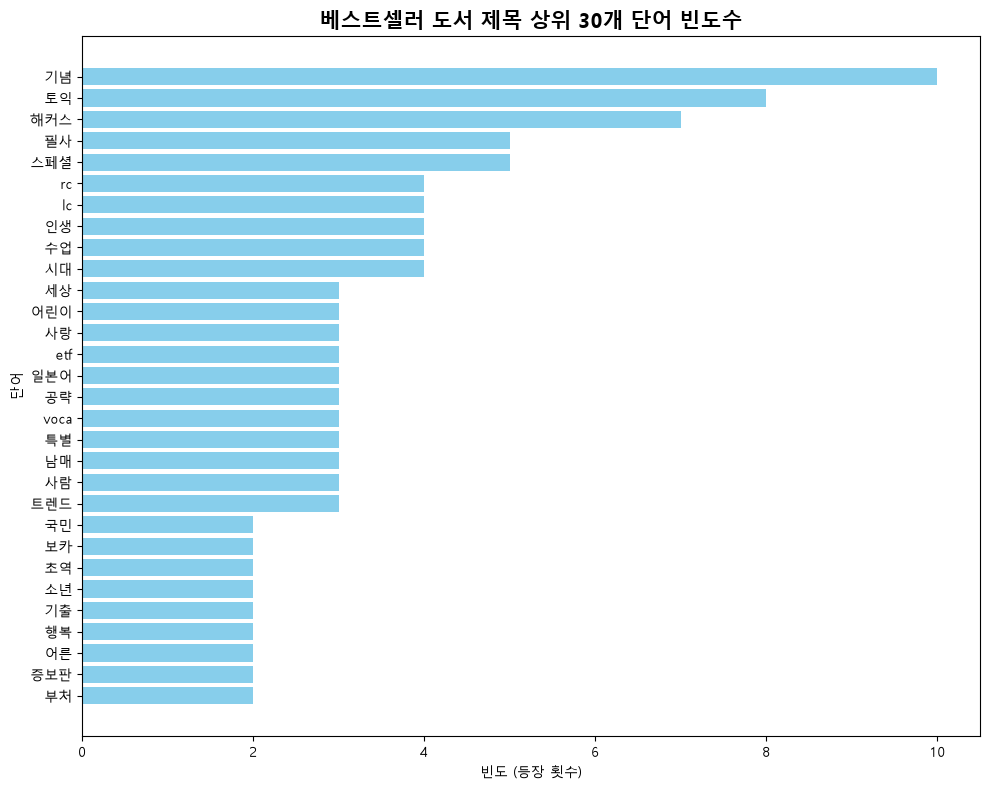

In [19]:
import matplotlib.pyplot as plt

# 1. 🚨 필수: 그래프에서 한글이 깨지지 않도록 '맑은 고딕(Windows 기본 폰트)' 설정하기
plt.rcParams["font.family"] = "Malgun Gothic"
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 2. 데이터 정렬하기 (가장 많은 단어가 위로 올라가도록 오름차순 정렬)
plot_data = top30.sort_values("빈도", ascending=True)

# 3. 그래프 도화지 크기 설정
plt.figure(figsize=(10, 8))

# 4. 가로형 막대그래프(barh) 그리기
plt.barh(plot_data["단어"], plot_data["빈도"], color="skyblue")

# 5. 그래프 꾸미기 (축 이름과 제목)
plt.xlabel("빈도 (등장 횟수)")
plt.ylabel("단어")
plt.title("베스트셀러 도서 제목 상위 30개 단어 빈도수", fontsize=15, fontweight="bold")

# 6. 여백을 깔끔하게 조정하고 화면에 출력!
plt.tight_layout()
plt.show()

### 📊 실습 19 최종 결과 요약: 완벽한 막대그래프 시각화 성공!

* **에러 완벽 해결**: 제목에서 이모지를 제거하여 폰트 깨짐 현상 없이 깔끔한 제목("베스트셀러 도서 제목 상위 30개 단어 빈도수")이 출력되었습니다.[cite: 2]
* **✅ 3가지 체크 포인트 최종 확인**:
  1. **한글 폰트 정상 출력**: '맑은 고딕' 폰트 설정이 완벽하게 적용되어 축 이름(단어, 빈도)과 항목들이 네모 박스(▯) 깨짐 없이 명확하게 보입니다.[cite: 2]
  2. **데이터 일치 여부**: 앞서 확인했던 표 결과와 동일하게 1위 '기념(10회)', 2위 '토익(8회)'이 그래프의 최상단에 정확히 위치하고 있습니다.[cite: 2]
  3. **시각적 비례 확인**: 막대의 길이가 X축의 빈도 숫자와 정확하게 비례하여 그려졌습니다.[cite: 2]
* **💡 시각화의 힘(인사이트)**: 딱딱한 숫자 표(DataFrame)로 볼 때보다 막대그래프로 보니, '기념', '토익', '해커스' 상위 3개 단어가 다른 단어들에 비해 얼마나 압도적인 비중을 차지하는지 한눈에 직관적으로 파악할 수 있습니다.[cite: 2]

### ☁️ 실습 20. 멋진 그림을 그리기 위한 붓과 물감, 'Word Cloud' 설치하기

데이터가 완벽하게 준비되었으니, 이제 이 단어들을 시각적으로 아름답게 배치해 줄 **워드클라우드(Word Cloud)** 라이브러리를 설치할 차례입니다.

#### 1. 터미널에서 설치하기
VS Code의 **터미널(Terminal)** 창을 열고(가상환경 켜져 있는지 확인!) 아래 명령어를 복사해 넣고 Enter를 누릅니다.
```bash
python -m pip install wordcloud matplotlib

In [20]:
from pathlib import Path

# 1. Windows 기본 한글 폰트인 '맑은 고딕'의 일반적인 위치를 지정합니다.
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")

# 2. 내 컴퓨터의 해당 위치에 진짜로 폰트 파일이 있는지 똑똑하게 검사합니다.
is_font_exists = FONT_PATH.exists()

print(f"✅ 한글 폰트 존재 여부: {is_font_exists}")

# 3. 결과에 따른 안내 메시지 출력
if is_font_exists:
    print("훌륭합니다! 한글이 깨지지 않는 워드클라우드를 그릴 완벽한 준비가 되었습니다 🎨")
else:
    print("앗, 결과가 False입니다. 윈도우 탐색기에서 C:/Windows/Fonts/ 폴더로 들어가 다른 한글 폰트를 찾거나 경로를 수정해 주세요!")

✅ 한글 폰트 존재 여부: True
훌륭합니다! 한글이 깨지지 않는 워드클라우드를 그릴 완벽한 준비가 되었습니다 🎨


### ☁️ 실습 22 최종 결과 요약: 데이터, 예술이 되다 (워드클라우드 완성!)

정제된 숫자 데이터(단어 빈도)를 시각적으로 가장 아름답고 직관적으로 보여주는 워드클라우드를 성공적으로 생성했습니다.

* **워드클라우드의 핵심 설정값(Parameter)**:
  * `generate_from_frequencies()`: 3중 필터로 정제해 만든 완벽한 빈도 데이터(`final_counter`)를 바로 그림으로 바꿔주는 핵심 마법입니다.
  * `random_state=42`: 단어들이 화면에 무작위로 흩뿌려지는데, 이 값을 고정해두면 누가 언제 코드를 다시 돌려도 똑같은 배치의 그림을 얻을 수 있습니다.
  * `axis("off")`: 그래프의 거추장스러운 X축, Y축 눈금을 없애주어 완벽한 한 폭의 그림처럼 보이게 만듭니다.
* **이미지 파일 영구 저장 (`.to_file`)**:
  완성된 워드클라우드를 `chapter02_wordcloud.png` 파일로 저장했습니다 (`True` 확인 완료). 이제 이 예쁜 이미지를 기획서나 결과 보고서 PPT에 바로 복사해 넣을 수 있습니다!
* **💡 Chapter 02 최종 회고**:
  단순한 문자열(도서 제목)에서 시작해 **전처리(형태소 분석, 노이즈 제거, 불용어 처리) → 빈도 분석 → 데이터 파일(CSV) 저장 → 시각화(막대그래프, 워드클라우드)**까지 이어지는 '데이터 분석의 전체 라이프 사이클'을 완벽하게 마스터했습니다!

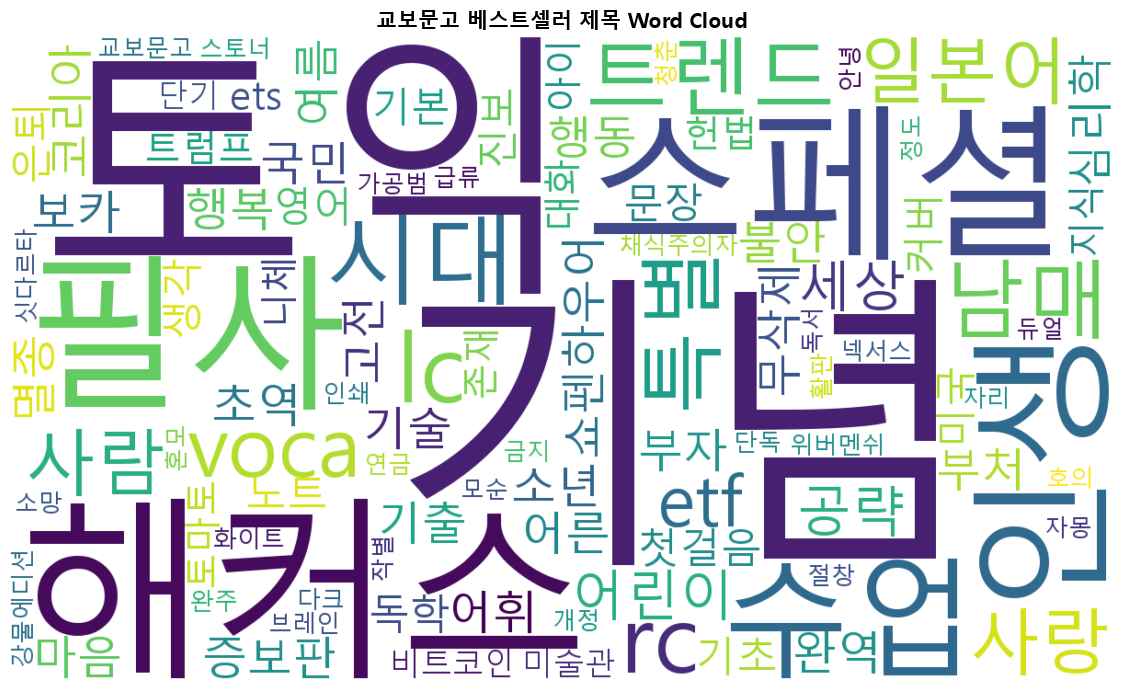


💾 워드클라우드 이미지 저장 성공 여부: True (chapter02_wordcloud.png 생성 완료!)


In [21]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pathlib import Path

# 1. 워드클라우드 도화지 설정 및 그림 그리기
wordcloud = WordCloud(
    font_path=str(FONT_PATH),      # 깨짐 방지용 한글 폰트 경로 (앞서 확인한 맑은 고딕)
    width=1200,                    # 가로 크기
    height=700,                    # 세로 크기
    background_color="white",      # 배경색 (흰색이 글자를 가장 돋보이게 합니다)
    max_words=100,                 # 최대 표현할 단어 수 (너무 많으면 지저분해짐)
    random_state=42,               # 랜덤 배치 고정 (실행할 때마다 똑같이 예쁜 배치가 나오도록)
).generate_from_frequencies(final_counter) # 우리가 만든 완벽한 빈도 데이터(Counter) 투입!

# 2. 화면에 예쁘게 띄우기
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear") # 이미지를 부드럽게 렌더링
plt.axis("off")                                 # 가로/세로 축 숫자와 눈금 숨기기 (그림처럼 보이게!)
plt.title("교보문고 베스트셀러 제목 Word Cloud", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. 완성된 멋진 그림을 내 컴퓨터에 이미지 파일(PNG)로 영구 저장하기
file_name = "chapter02_wordcloud.png"
wordcloud.to_file(file_name)

# 4. 파일이 잘 저장되었는지 스마트하게 확인
is_saved = Path(file_name).exists()
print(f"\n💾 워드클라우드 이미지 저장 성공 여부: {is_saved} ({file_name} 생성 완료!)")

### 🎉 Chapter 02 최종 완료: 워드클라우드 시각화 성공!

* **시각화 결과 분석**: 
  * 완성된 워드클라우드 이미지를 확인해 보면, '토익', '기념', '해커스', '스페셜', '필사' 등 빈도수가 높았던 핵심 키워드들이 화면 중앙에 가장 큰 글씨로 강조되어 나타났습니다.
  * 막대그래프가 '정확한 수치 비교'에 탁월하다면, 워드클라우드는 '전체적인 트렌드와 키워드의 비중'을 직관적으로 보여주어 보고서나 발표 자료에 활용하기 아주 좋은 도구임을 확인했습니다.
* **성공적인 데이터 분석 파이프라인 완주**:
  * 단순한 텍스트 덩어리였던 도서 제목 데이터가 **형태소 분석(Kiwi) → 3중 필터링 및 불용어 제거 → 빈도 분석(Counter) → CSV 저장 → 시각화(막대그래프 & Word Cloud)** 라는 완벽한 데이터 정제 과정을 거쳐 의미 있는 그림으로 재탄생했습니다!